<a href="https://colab.research.google.com/github/DAleid/Fraud-Detection-Model/blob/main/fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection

**Goal:** detect fraudulent transactions in a highly imbalanced dataset (~0.17% fraud).

**Dataset:** [Kaggle: Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) (284,807 transactions; `V1`-`V28` are anonymised PCA features).

**Approach:** stratified train/validation/test split, class weighting for imbalance, three models compared using precision-recall metrics, and a decision threshold tuned on validation data only.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score, recall_score,
    f1_score, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
)

SEED = 42

## 1. Load data

In [2]:
import os, kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(os.path.join(path, "creditcard.csv"))
print(df.shape)
df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Exploratory data analysis
Accuracy is a misleading metric here: a model that always predicts "legit" would score ~99.8%. So we evaluate with **PR-AUC, precision and recall**.

Fraud rate: 0.173%
Missing values: 0 | Duplicate rows: 1081


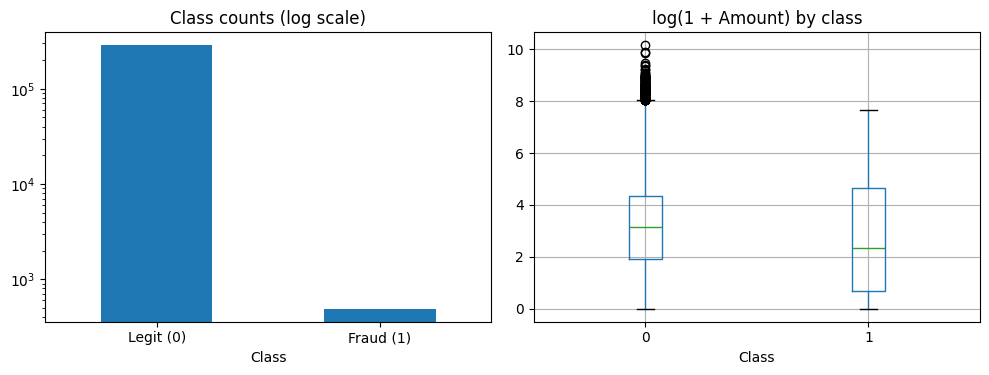

In [3]:
counts = df["Class"].value_counts()
print(f"Fraud rate: {counts[1] / len(df) * 100:.3f}%")
print("Missing values:", df.isna().sum().sum(), "| Duplicate rows:", df.duplicated().sum())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts.plot(kind="bar", ax=axes[0], logy=True, title="Class counts (log scale)")
axes[0].set_xticklabels(["Legit (0)", "Fraud (1)"], rotation=0)
df.assign(log_amount=np.log1p(df["Amount"])).boxplot(column="log_amount", by="Class", ax=axes[1])
axes[1].set_title("log(1 + Amount) by class")
fig.suptitle("")
plt.tight_layout()
plt.show()

## 3. Preprocessing
Stratified split keeps the fraud ratio equal in every set. The scaler is fit on the **training set only** to avoid data leakage. Only `Time` and `Amount` need scaling because `V1`-`V28` are already PCA outputs.

In [4]:
X, y = df.drop(columns="Class"), df["Class"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
X_tr, X_val, y_tr, y_val = train_test_split(X_tr, y_tr, test_size=0.25, stratify=y_tr, random_state=SEED)
X_tr, X_val, X_te = X_tr.copy(), X_val.copy(), X_te.copy()

cols = ["Time", "Amount"]
scaler = StandardScaler().fit(X_tr[cols])
for part in (X_tr, X_val, X_te):
    part[cols] = scaler.transform(part[cols])

print("Train / val / test:", len(X_tr), len(X_val), len(X_te))
print("Fraud in each:", y_tr.sum(), y_val.sum(), y_te.sum())

Train / val / test: 170883 56962 56962
Fraud in each: 295 99 98


## 4. Models
Imbalance is handled with **class weights** (errors on fraud cost more). Three models are compared: a linear baseline, a bagging ensemble and gradient boosting.

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced_subsample", n_jobs=-1, random_state=SEED),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=SEED),
}
sample_weight = compute_sample_weight("balanced", y_tr)

for name, model in models.items():
    print("Training", name)
    if name == "Gradient Boosting":
        model.fit(X_tr, y_tr, sample_weight=sample_weight)
    else:
        model.fit(X_tr, y_tr)

Training Logistic Regression
Training Random Forest
Training Gradient Boosting


## 5. Evaluation
The decision threshold is chosen to maximise F1 on the **validation** set, then applied unchanged to the **test** set. Choosing it on test data would leak information and inflate results.

In [6]:
def best_threshold(y_true, scores):
    p, r, t = precision_recall_curve(y_true, scores)
    f1 = 2 * p * r / (p + r + 1e-12)
    return t[int(np.nanargmax(f1[:-1]))]

rows, test_scores, val_ap = [], {}, {}
for name, model in models.items():
    val_scores = model.predict_proba(X_val)[:, 1]
    val_ap[name] = average_precision_score(y_val, val_scores)
    thr = best_threshold(y_val, val_scores)

    scores = model.predict_proba(X_te)[:, 1]
    test_scores[name] = scores
    pred = (scores >= thr).astype(int)
    rows.append({
        "model": name,
        "PR-AUC": average_precision_score(y_te, scores),
        "ROC-AUC": roc_auc_score(y_te, scores),
        "precision": precision_score(y_te, pred, zero_division=0),
        "recall": recall_score(y_te, pred),
        "F1": f1_score(y_te, pred),
        "threshold": thr,
    })

results = pd.DataFrame(rows).round(4)
results

,model,PR-AUC,ROC-AUC,precision,recall,F1,threshold
0,Logistic Regression,0.7209,0.9726,0.8000,0.8163,0.8081,1.000
1,Random Forest,0.8438,0.9572,0.8817,0.8367,0.8586,0.230
2,Gradient Boosting,0.7403,0.9552,0.8081,0.8163,0.8122,0.928


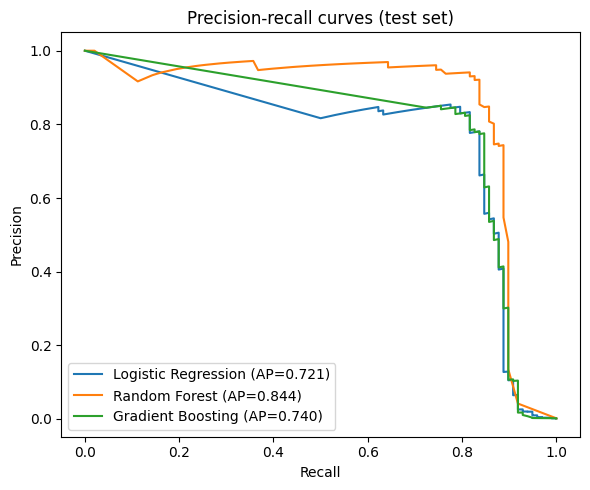

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, scores in test_scores.items():
    p, r, _ = precision_recall_curve(y_te, scores)
    ax.plot(r, p, label=f"{name} (AP={average_precision_score(y_te, scores):.3f})")
ax.set(xlabel="Recall", ylabel="Precision", title="Precision-recall curves (test set)")
ax.legend()
plt.tight_layout()
plt.show()

### Best model: confusion matrix
The best model is picked by **validation** PR-AUC. Each false negative is a missed fraud; each false positive is a legitimate customer flagged and an analyst's time spent reviewing it.

Best model (by validation PR-AUC): Random Forest


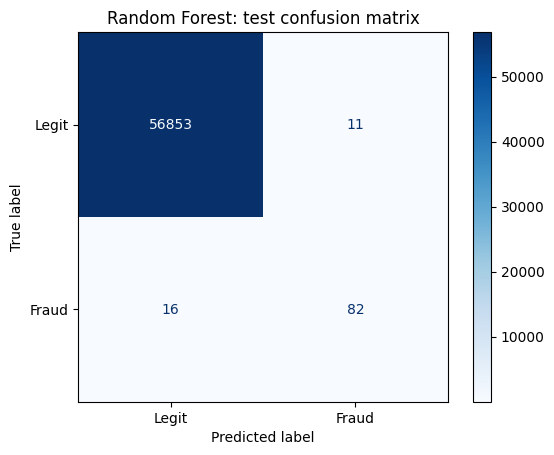

In [8]:
best = max(val_ap, key=val_ap.get)
thr = results.loc[results["model"] == best, "threshold"].iloc[0]
pred = (test_scores[best] >= thr).astype(int)
print("Best model (by validation PR-AUC):", best)

ConfusionMatrixDisplay(confusion_matrix(y_te, pred), display_labels=["Legit", "Fraud"]).plot(cmap="Blues")
plt.title(f"{best}: test confusion matrix")
plt.show()

## 6. Feature importance

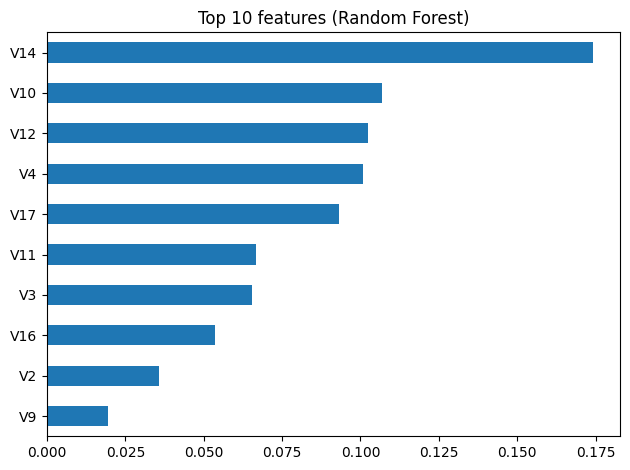

In [9]:
rf = models["Random Forest"]
imp = pd.Series(rf.feature_importances_, index=X_tr.columns).nlargest(10)
imp.sort_values().plot(kind="barh", title="Top 10 features (Random Forest)")
plt.tight_layout()
plt.show()

## 7. Conclusions


- Best model: Random Forest, PR-AUC 0.84, recall 0.84 at precision 0.88 on the held-out test set.
- Class weighting and threshold tuning were needed because only ~0.17% of transactions are fraud.
- **Limitations:** features are anonymised, so decisions can't be explained in business terms; a single random split was used (time-based validation would be more realistic).
- **Next steps:** SMOTE comparison, SHAP explanations, and an LLM layer that turns flagged transactions into short analyst-facing alert summaries.